In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/city_lifestyle_dataset.csv')

# Initial profile
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())  # Should be all zeros[reference:13]

# Check data types
print(df.dtypes)

Shape: (300, 10)
Columns: ['city_name', 'country', 'population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory us

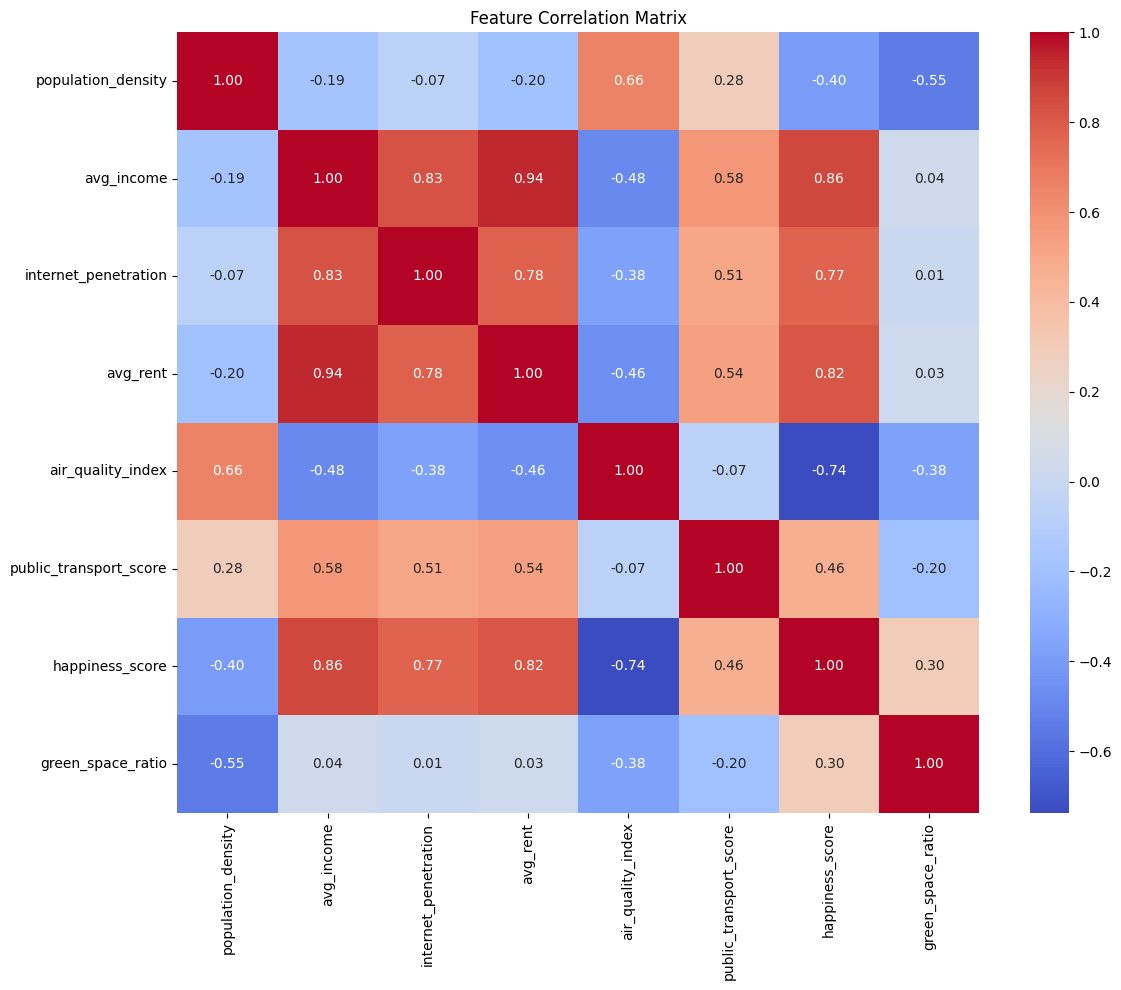

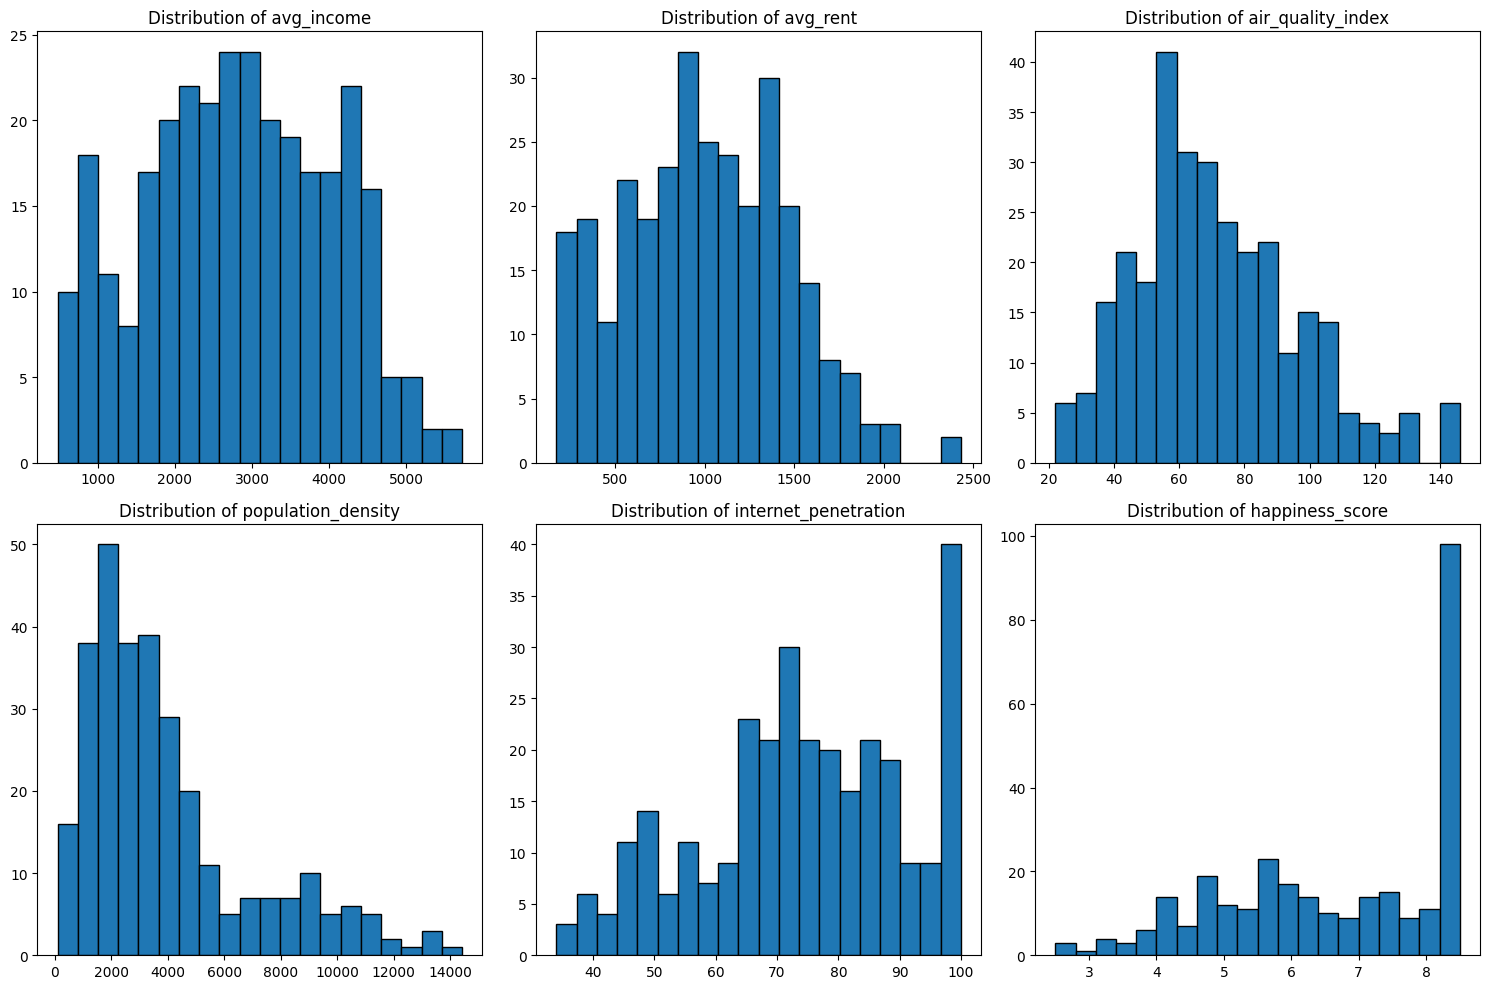

In [2]:
# Correlation matrix
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../correlation_matrix.png')
plt.show()

# Distribution of key features - UPDATED WITH YOUR EXACT COLUMN NAMES
features_to_plot = ['avg_income', 'avg_rent', 'air_quality_index', 'population_density', 'internet_penetration', 'happiness_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, feat in enumerate(features_to_plot):
    row, col = i // 3, i % 3
    axes[row, col].hist(df[feat], bins=20, edgecolor='black')
    axes[row, col].set_title(f'Distribution of {feat}')
plt.tight_layout()
plt.savefig('../feature_distributions.png')
plt.show()

In [3]:
# One-Hot Encoding for country
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)

# Drop city_name (it's an identifier, not a feature)
X = df_encoded.drop(['city_name'], axis=1)

# Verify all features are now numeric
print(X.dtypes)
print(f"\nFeature columns: {X.columns.tolist()}")

population_density          int64
avg_income                  int64
internet_penetration      float64
avg_rent                    int64
air_quality_index           int64
public_transport_score    float64
happiness_score           float64
green_space_ratio         float64
country_Asia                 bool
country_Europe               bool
country_North America        bool
country_Oceania              bool
country_South America        bool
dtype: object

Feature columns: ['population_density', 'avg_income', 'internet_penetration', 'avg_rent', 'air_quality_index', 'public_transport_score', 'happiness_score', 'green_space_ratio', 'country_Asia', 'country_Europe', 'country_North America', 'country_Oceania', 'country_South America']


In [4]:
from sklearn.preprocessing import StandardScaler

# All columns in X are numeric features (country was one-hot encoded)
feature_cols = X.columns.tolist()  # This automatically excludes city_name

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[feature_cols])

# Convert back to DataFrame for interpretability
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print(X_scaled_df.head())

   population_density  avg_income  internet_penetration  avg_rent  \
0           -0.392882    0.852930              0.712033  0.674466   
1           -0.028158    0.727843              0.223398  0.718372   
2           -0.464417    1.236532              0.341141  0.718372   
3           -0.252836    0.953000              0.405900  1.047665   
4           -0.150740    1.244871              1.512687  1.113524   

   air_quality_index  public_transport_score  happiness_score  \
0          -1.116351               -0.253086         1.102759   
1          -1.155872                0.482207         0.865095   
2          -1.274437                1.190268         1.102759   
3          -0.444485               -0.443718         1.102759   
4          -0.286399                2.585965         1.102759   

   green_space_ratio  country_Asia  country_Europe  country_North America  \
0          -1.082287     -0.603023             2.0              -0.447214   
1          -0.094850     -0.603023      

In [5]:
# Use IQR method on scaled data
Q1 = X_scaled_df.quantile(0.25)
Q3 = X_scaled_df.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((X_scaled_df < (Q1 - 1.5 * IQR)) | 
                (X_scaled_df > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Number of outliers detected: {outlier_mask.sum()}")

# Justification: For density-based clustering (HDBSCAN), 
# outliers are naturally handled by the algorithm, so we keep them.
print("We keep outliers because HDBSCAN will identify them as noise points (label = -1).")

Number of outliers detected: 211
We keep outliers because HDBSCAN will identify them as noise points (label = -1).


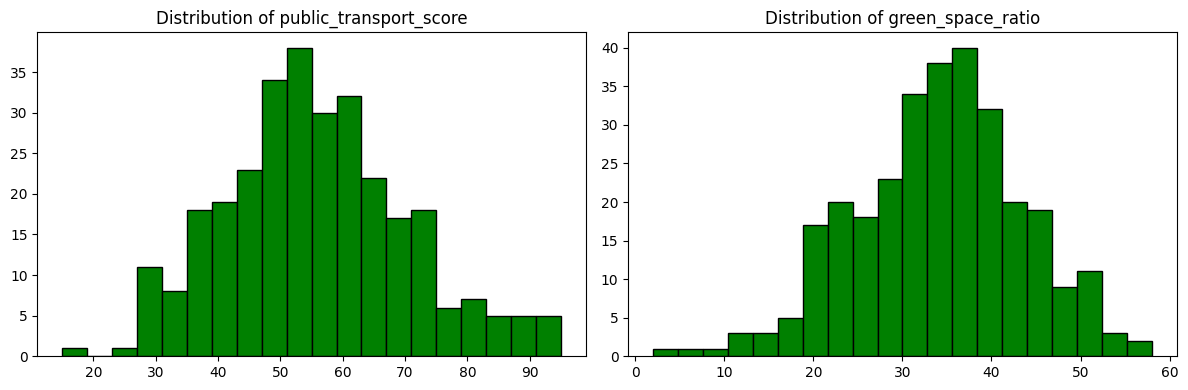


Correlation with avg_income:
                        avg_income  public_transport_score  green_space_ratio
avg_income                1.000000                0.577541           0.038687
public_transport_score    0.577541                1.000000          -0.202795
green_space_ratio         0.038687               -0.202795           1.000000


In [6]:
# Additional feature distribution
extra_features = ['public_transport_score', 'green_space_ratio']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, feat in enumerate(extra_features):
    axes[i].hist(df[feat], bins=20, edgecolor='black', color='green')
    axes[i].set_title(f'Distribution of {feat}')
plt.tight_layout()
plt.savefig('../extra_feature_distributions.png')
plt.show()

# Check correlation with key economic features
print("\nCorrelation with avg_income:")
print(df[['avg_income', 'public_transport_score', 'green_space_ratio']].corr())